# 🌳 Paso 4 — Clasificación con Decision Tree
**Dataset:** Consumo eléctrico industrial
**Objetivo:** Entrenar un árbol de decisión para predecir `Load_Type` y encontrar la profundidad óptima

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score)
from sklearn.model_selection import cross_val_score

os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/results', exist_ok=True)
sns.set_theme(style='whitegrid')
print('✅ Librerías cargadas')

✅ Librerías cargadas


## 1. Cargar los datos procesados

In [2]:
X_train = pd.read_csv('data/processed/X_train.csv')
X_test  = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('data/processed/y_test.csv').squeeze()

CLASES        = ['Light_Load', 'Maximum_Load', 'Medium_Load']
FEATURE_NAMES = list(X_train.columns)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Features: {FEATURE_NAMES}')
print('✅ Datos cargados correctamente')

X_train: (27967, 9) | X_test: (6992, 9)
Features: ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week']
✅ Datos cargados correctamente


## 2. Buscar la profundidad óptima (max_depth)
Probamos profundidades del 1 al 20 con validación cruzada de 5 folds.

In [3]:
rango_depth     = range(1, 21)
accuracies_cv   = []
accuracies_test = []

for depth in rango_depth:
    dt = DecisionTreeClassifier(max_depth=depth, criterion='gini', random_state=42)
    cv_score   = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy').mean()
    dt.fit(X_train, y_train)
    test_score = accuracy_score(y_test, dt.predict(X_test))
    accuracies_cv.append(cv_score)
    accuracies_test.append(test_score)

mejor_depth = rango_depth[np.argmax(accuracies_cv)]
print(f'Mejor profundidad encontrada: {mejor_depth}')
print(f'Accuracy CV   con depth={mejor_depth}: {max(accuracies_cv):.4f}')
print(f'Accuracy Test con depth={mejor_depth}: {accuracies_test[mejor_depth-1]:.4f}')

Mejor profundidad encontrada: 13
Accuracy CV   con depth=13: 0.8970
Accuracy Test con depth=13: 0.8982


## 3. Gráfica — Accuracy vs Profundidad

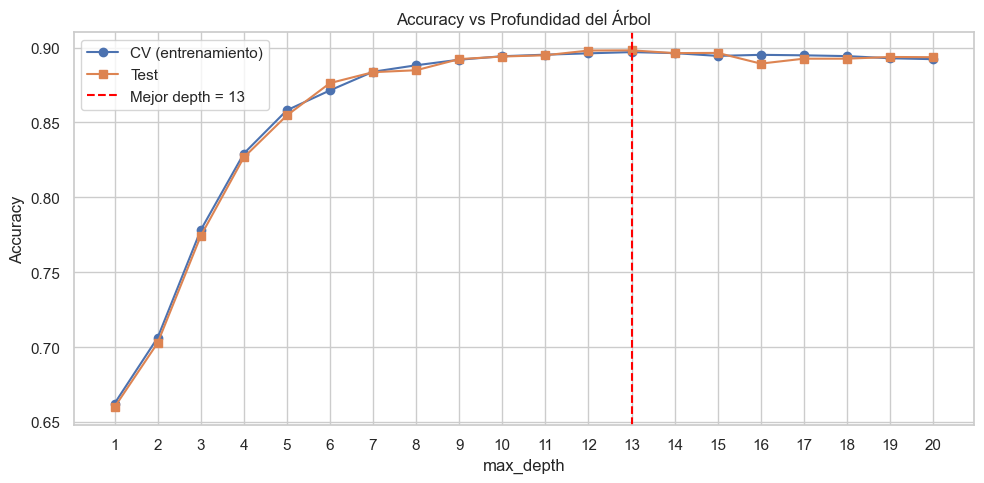

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(rango_depth, accuracies_cv,   marker='o', label='CV (entrenamiento)', color='#4C72B0')
plt.plot(rango_depth, accuracies_test, marker='s', label='Test',               color='#DD8452')
plt.axvline(x=mejor_depth, color='red', linestyle='--', label=f'Mejor depth = {mejor_depth}')
plt.title('Accuracy vs Profundidad del Árbol')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.xticks(rango_depth)
plt.legend()
plt.tight_layout()
plt.savefig('outputs/figures/dt_accuracy_vs_depth.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Entrenar el modelo final con la mejor profundidad

In [5]:
dt_final = DecisionTreeClassifier(max_depth=mejor_depth, criterion='gini', random_state=42)
dt_final.fit(X_train, y_train)
y_pred_dt = dt_final.predict(X_test)

print(f'✅ Árbol de decisión entrenado')
print(f'   Profundidad:       {dt_final.get_depth()}')
print(f'   Número de hojas:   {dt_final.get_n_leaves()}')
print(f'   Número de nodos:   {dt_final.tree_.node_count}')

✅ Árbol de decisión entrenado
   Profundidad:       13
   Número de hojas:   613
   Número de nodos:   1225


## 5. Métricas de evaluación

In [6]:
acc = accuracy_score(y_test, y_pred_dt)
print(f'Accuracy: {acc:.4f} ({acc*100:.2f}%)')
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_dt, target_names=CLASES))

Accuracy: 0.8982 (89.82%)

Reporte de clasificación:
              precision    recall  f1-score   support

  Light_Load       0.97      0.97      0.97      3599
Maximum_Load       0.81      0.83      0.82      1454
 Medium_Load       0.83      0.82      0.83      1939

    accuracy                           0.90      6992
   macro avg       0.87      0.87      0.87      6992
weighted avg       0.90      0.90      0.90      6992



## 6. Matriz de confusión

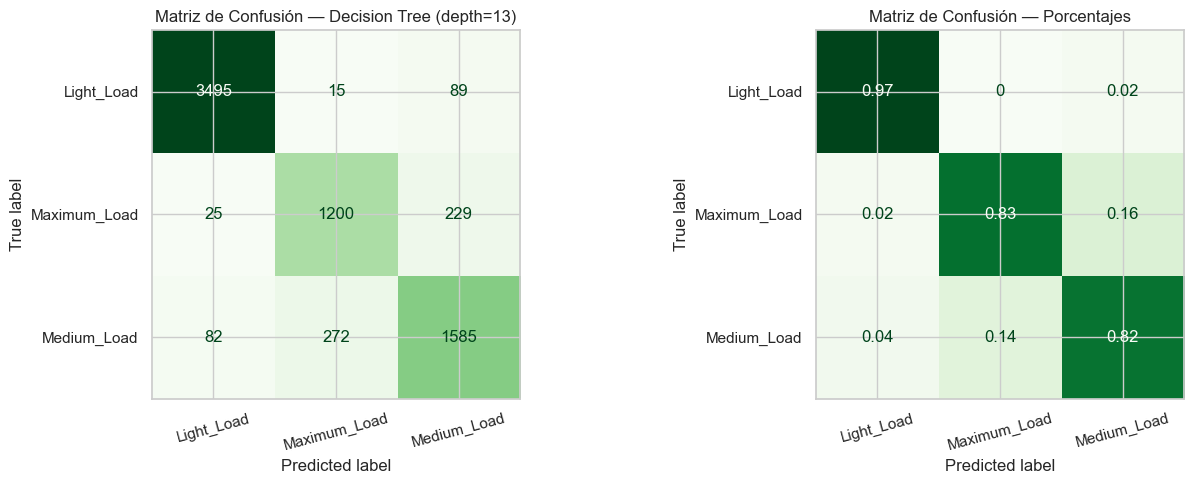

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm, display_labels=CLASES).plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title(f'Matriz de Confusión — Decision Tree (depth={mejor_depth})')
axes[0].tick_params(axis='x', rotation=15)

cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(np.round(cm_pct, 2), display_labels=CLASES).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Matriz de Confusión — Porcentajes')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('outputs/figures/dt_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Importancia de las variables (feature importance)

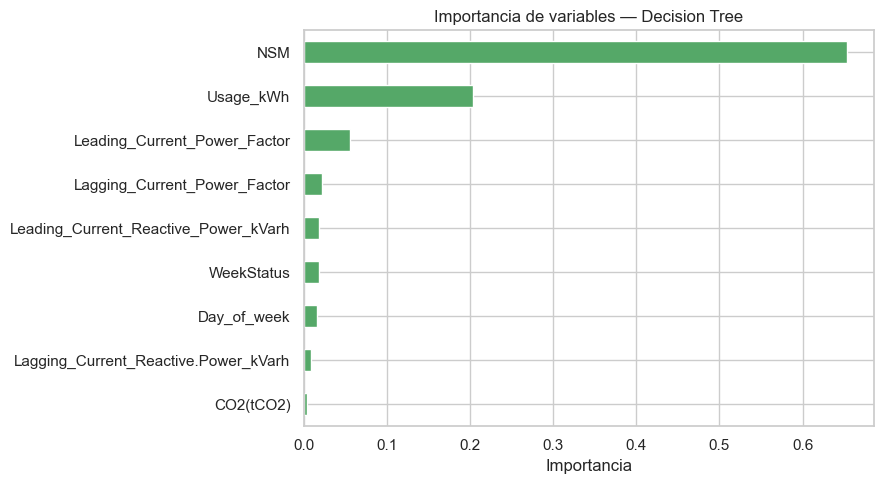


Top 3 variables más importantes:
NSM                             0.653177
Usage_kWh                       0.203042
Leading_Current_Power_Factor    0.056054
dtype: float64


In [8]:
importancias = pd.Series(dt_final.feature_importances_, index=FEATURE_NAMES)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(9, 5))
importancias.plot(kind='barh', color='#55A868', edgecolor='white')
plt.title('Importancia de variables — Decision Tree')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('outputs/figures/dt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 3 variables más importantes:')
print(importancias.sort_values(ascending=False).head(3))

## 8. Visualización del árbol de decisión

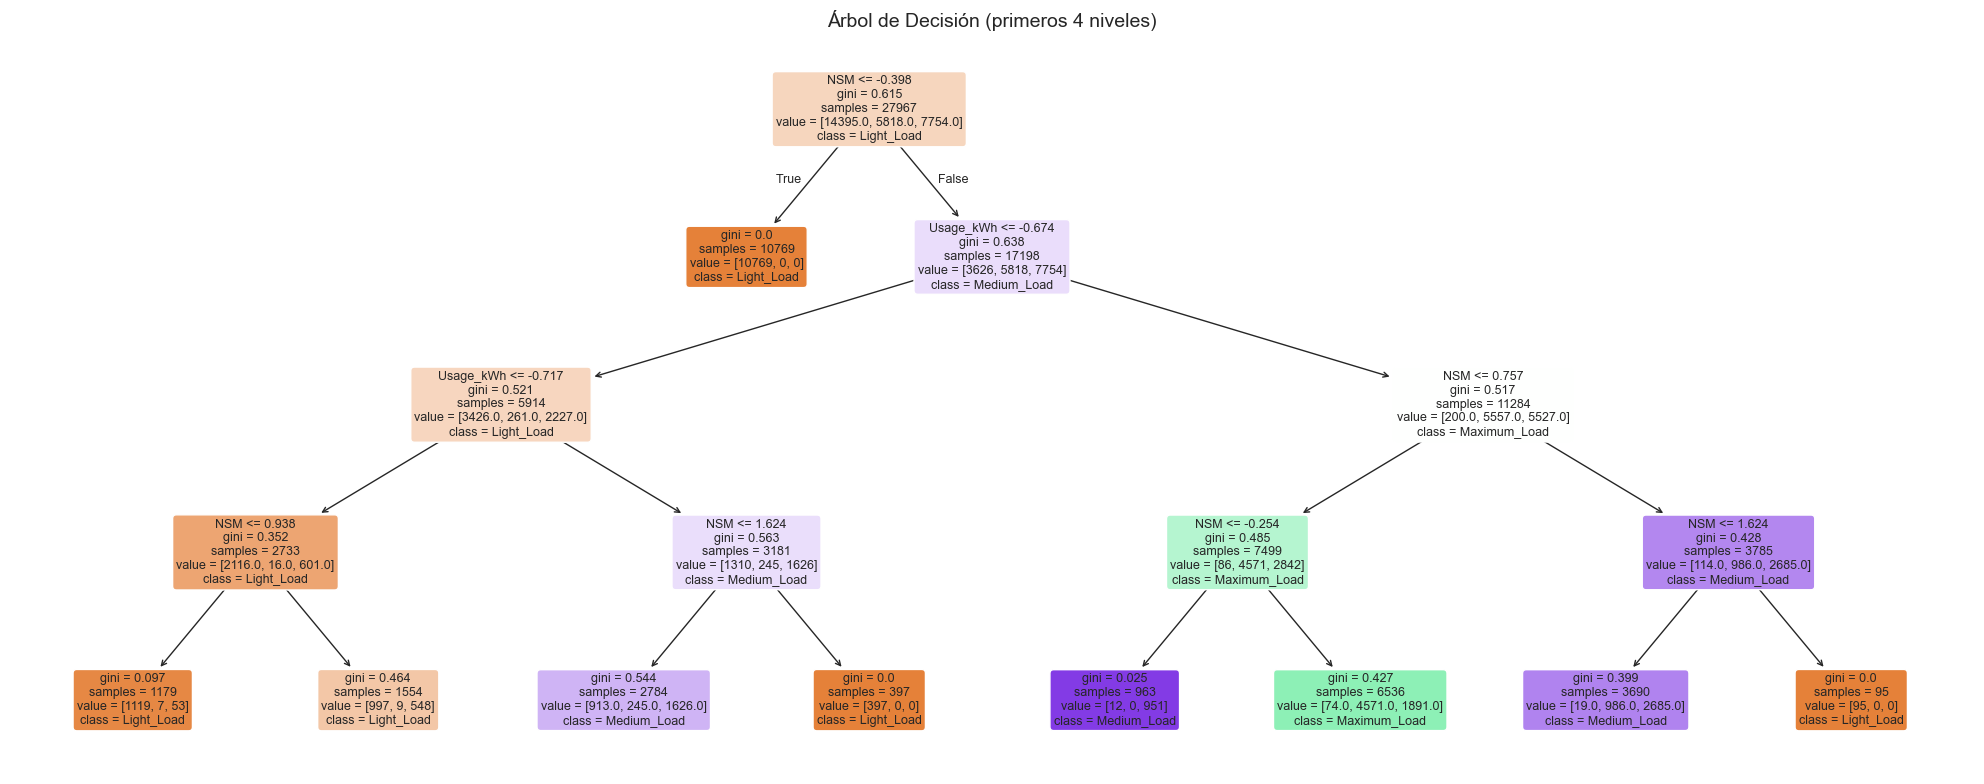

✅ Árbol visualizado con 4 niveles (guardado en outputs/figures/)


In [9]:
profundidad_visual = min(mejor_depth, 4)  # Máximo 4 niveles para que sea legible

dt_visual = DecisionTreeClassifier(max_depth=profundidad_visual, criterion='gini', random_state=42)
dt_visual.fit(X_train, y_train)

plt.figure(figsize=(20, 8))
plot_tree(dt_visual,
          feature_names=FEATURE_NAMES,
          class_names=CLASES,
          filled=True,
          rounded=True,
          fontsize=9,
          impurity=True,
          proportion=False)
plt.title(f'Árbol de Decisión (primeros {profundidad_visual} niveles)', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/figures/dt_arbol.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Árbol visualizado con {profundidad_visual} niveles (guardado en outputs/figures/)')

## 9. Guardar resultados

In [10]:
resultados_dt = pd.DataFrame([{
    'Modelo':      'Decision Tree',
    'Mejor_depth': mejor_depth,
    'Accuracy':    round(accuracy_score(y_test, y_pred_dt), 4),
    'Precision':   round(precision_score(y_test, y_pred_dt, average='weighted'), 4),
    'Recall':      round(recall_score(y_test, y_pred_dt, average='weighted'), 4),
    'F1_Score':    round(f1_score(y_test, y_pred_dt, average='weighted'), 4)
}])

resultados_dt.to_csv('outputs/results/resultados_dt.csv', index=False)
print('✅ Resultados guardados en outputs/results/resultados_dt.csv')
print(resultados_dt.to_string(index=False))
print('\n✅ Decision Tree completado. Continúa con 05_comparacion.ipynb')

✅ Resultados guardados en outputs/results/resultados_dt.csv
       Modelo  Mejor_depth  Accuracy  Precision  Recall  F1_Score
Decision Tree           13    0.8982     0.8982  0.8982    0.8982

✅ Decision Tree completado. Continúa con 05_comparacion.ipynb
